# Truncated SVD (TSVD) — Image Reconstruction (16×16 Patch)

## Inverse Problem

$$
y = A\,x + \varepsilon
$$

## Singular Value Decomposition

The forward operator has the SVD:

$$
A = U\,\Sigma\,V^T = \sum_{i=1}^{r} \sigma_i\, u_i\, v_i^T
$$

## Naive Pseudoinverse (ill-posed!)

$$
x^{\dagger} = A^{\dagger}\,y = \sum_{i=1}^{r} \frac{u_i^T y}{\sigma_i}\, v_i
$$

Small singular values $\sigma_i$ amplify noise $\Rightarrow$ reconstruction blows up.

## TSVD Regularization

Truncate at index $k$, keeping only the $k$ largest singular values:

$$
x_k = \sum_{i=1}^{k} \frac{u_i^T y}{\sigma_i}\, v_i
$$

This discards noise-dominated components where $\sigma_i \approx 0$.

## Why 16×16 Patch?

Building the explicit convolution matrix $A \in \mathbb{R}^{N \times N}$ for a full image is infeasible (e.g., 321×481 image would require 154401×154401 matrix = 177GB). We extract a **16×16 patch** ($N = 256$) for demonstration.

## Error Metrics

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(x_i^{\text{rec}} - x_i^{\text{true}})^2, \qquad
\text{Relative Error} = \frac{\|x^{\text{rec}} - x^{\text{true}}\|}{\|x^{\text{true}}\|}
$$

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from numpy.linalg import svd

In [8]:
image_path = r"296059.jpg"
img = plt.imread(image_path)


if img.ndim == 3:
    img = img.mean(axis=2)


x = img.astype(float)
x = x / x.max()


n = x.shape[0]
print("Image shape:", x.shape)

Image shape: (321, 481)


In [ ]:
# Extract 16x16 patch for TSVD (explicit matrix construction is only feasible for small patches)
patch_size = 16
x_true = x.copy()

# Extract patch from center region
start_row, start_col = 100, 100
patch = x_true[start_row:start_row+patch_size, start_col:start_col+patch_size]
patch = patch / patch.max()

print(f"Full image size: {x.shape[0]} x {x.shape[1]}")
print(f"Extracted patch size: {patch_size} x {patch_size}")
print(f"Matrix size will be: {patch_size**2} x {patch_size**2}")

Image size: 321 x 321
Kernel size: 9x9, sigma: 2.0
Kernel/Image ratio: 0.028037383177570093 (should be < 0.3 for good results)


In [10]:
def gaussian_kernel(size=9, sigma=2.0):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel


kernel = gaussian_kernel()

In [ ]:
def build_convolution_matrix(kernel, patch_size):
    """Build explicit convolution matrix for a patch"""
    N = patch_size * patch_size
    A = np.zeros((N, N))
    for i in range(N):
        basis = np.zeros((patch_size, patch_size))
        basis.flat[i] = 1.0
        conv = convolve2d(basis, kernel, mode="same", boundary="symm")
        A[:, i] = conv.flatten()
    return A

print("Building convolution matrix for 16x16 patch...")
A = build_convolution_matrix(kernel, patch_size)
print(f"Matrix A shape: {A.shape}")

In [ ]:
# Apply forward model to the patch
Ax_patch = convolve2d(patch, kernel, mode="same", boundary="symm")
noise_std = 0.01
np.random.seed(42)
eps = noise_std * np.random.randn(*Ax_patch.shape)
y_patch = Ax_patch + eps

print(f"Noise level: {np.linalg.norm(eps):.6f}")

In [ ]:
# Perform SVD
print("Computing SVD...")
U, S, Vt = svd(A, full_matrices=False)

print(f"Condition number of A: {S[0]/S[-1]:.2e}")

plt.figure(figsize=(8, 5))
plt.semilogy(S, 'b-o', markersize=3)
plt.title("Singular Value Decay")
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.grid(True)
plt.show()

NameError: name 'A' is not defined

In [ ]:
def tsvd_reconstruction(U, S, Vt, y_vec, k):
    """TSVD reconstruction: keep first k singular components"""
    Uk = U[:, :k]
    Sk = S[:k]
    Vk = Vt[:k, :]
    return Vk.T @ (Uk.T @ y_vec / Sk)

# Vectorize patch data
x_vec = patch.flatten()
y_vec = y_patch.flatten()

<function matplotlib.pyplot.show(close=None, block=None)>

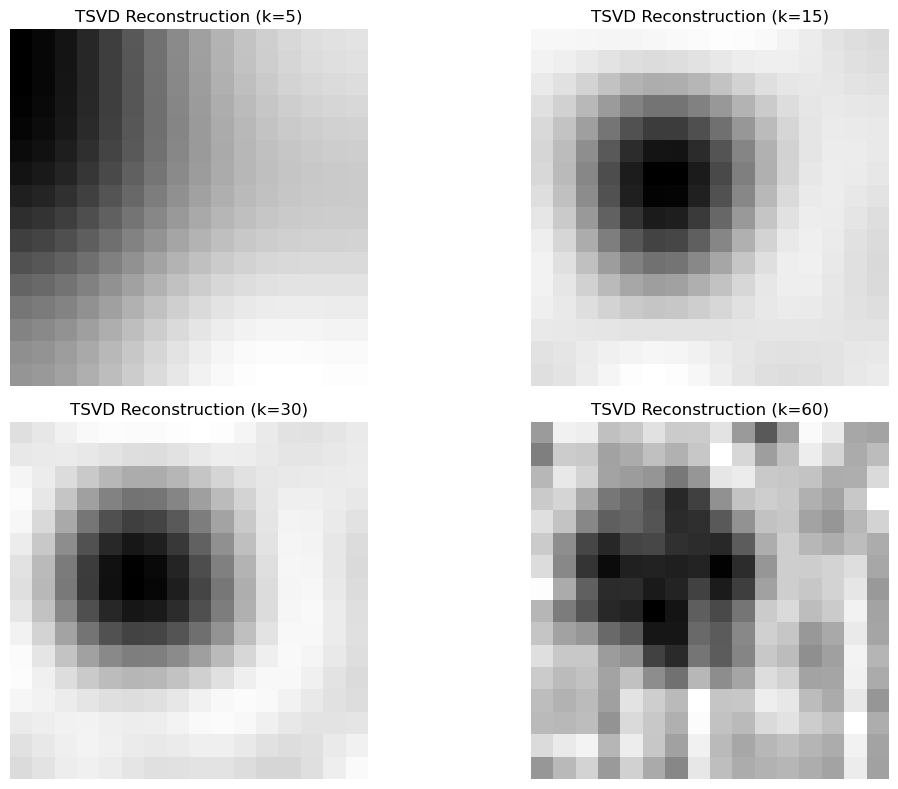

In [ ]:
ks = [5, 15, 30, 60]

plt.figure(figsize=(12, 8))
for i, k in enumerate(ks):
    xk = tsvd_reconstruction(U, S, Vt, y_vec, k).reshape(patch_size, patch_size)
    plt.subplot(2, 2, i+1)
    plt.imshow(xk, cmap="gray")
    plt.title(f"TSVD Reconstruction (k={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()

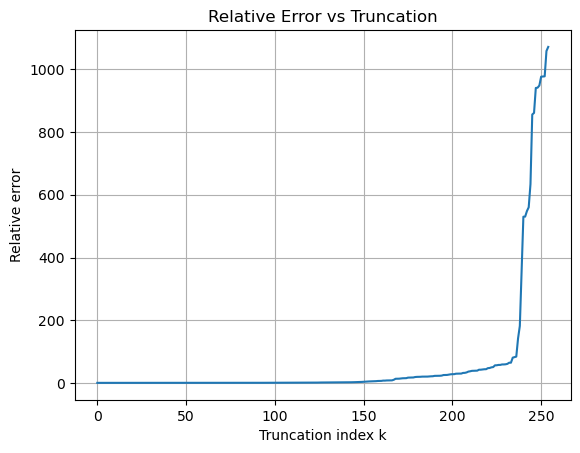

TSVD RECONSTRUCTION ERROR ANALYSIS
Best truncation k: 37
Best relative error: 0.135325
Condition number of A: 5.87e+07


In [ ]:
# Compute errors and MSE for all k values
errors = []
mse_vals = []
for k in range(1, len(S)):
    xk = tsvd_reconstruction(U, S, Vt, y_vec, k)
    err = np.linalg.norm(x_vec - xk) / np.linalg.norm(x_vec)
    mse_val = np.mean((x_vec - xk) ** 2)
    errors.append(err)
    mse_vals.append(mse_val)

# Plot error curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(errors)+1), errors, 'b-', linewidth=1.5)
axes[0].set_xlabel("Truncation index k")
axes[0].set_ylabel("Relative error")
axes[0].set_title("Relative Error vs Truncation")
axes[0].grid(True)

axes[1].plot(range(1, len(mse_vals)+1), mse_vals, 'r-', linewidth=1.5)
axes[1].set_xlabel("Truncation index k")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs Truncation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Find best k
best_k = np.argmin(errors) + 1
best_error = min(errors)
best_mse = mse_vals[best_k - 1]
x_best = tsvd_reconstruction(U, S, Vt, y_vec, best_k).reshape(patch_size, patch_size)

print("="*50)
print("TSVD RECONSTRUCTION ERROR ANALYSIS (16×16 PATCH)")
print("="*50)
print(f"Best truncation k: {best_k}")
print(f"Best relative error: {best_error:.6f}")
print(f"Best MSE: {best_mse:.8f}")
print(f"Condition number of A: {S[0]/S[-1]:.2e}")
print(f"Smallest singular value: {S[-1]:.2e}")
print(f"Largest singular value: {S[0]:.2e}")
print("="*50)